# HIT140 Assessment 2: Defender age and fouls at the FIFA World Cup 2026

**Analytic question:** Among defenders who played at the FIFA World Cup 2026, do older defenders commit fewer fouls per 90 minutes than younger defenders? Only defenders with at least N minutes on the field are included.

## Data Wrangling

### Data Acquisition

Player statistics are taken from FBref. Two tables for the 2026 World Cup were exported using the CSV export feature of the site.

| File | Table Name | Source |
|---|---|---|
| `data/raw/fbref_player_standard.csv` | Player Standard Stats (position, age, minutes, cards) | https://fbref.com/en/comps/1/stats/World-Cup-Stats |
| `data/raw/fbref_player_misc.csv` | Player Miscellaneous Stats (fouls, cards, tackles) | https://fbref.com/en/comps/1/misc/World-Cup-Stats |

### Cleaning

Opening the file in a text editor shows the table starts with the labels on the 6th row, so we skip the first 5 rows to get the data only

```
--- When using SR data, please cite us and provide a link and/or a mention.


 
,,,,,,,Performance,Performance,Performance,Performance,Performance,Performance,Performance,Performance,Performance,Performance,Performance,Performance,,-additional
Rk,Player,Pos,Squad,Age,Born,90s,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG,Matches,-9999
1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,0,0,2,1,0,1,0,1,,,0,Matches,5bc43860
2,Thelo Aasgaard,MF,no Norway,24,2002,1.0,0,0,0,0,3,0,0,3,1,,,0,Matches,c88a28b9
...
```

In [2]:
import pandas as pd
import numpy as np

standard = pd.read_csv("data/raw/fbref_player_standard.csv", skiprows=5)
misc = pd.read_csv("data/raw/fbref_player_misc.csv", skiprows=5)

print("standard:", standard.shape)
print("misc:", misc.shape)

standard.head()

standard: (1040, 26)
misc: (1039, 21)

,Rk,Player,Pos,Squad,Age,Club,Born,MP,Starts,Min,...,PKatt,CrdY,CrdR,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK,Matches,-9999
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9999
1,1.0,Brenden Aaronson,MF,us USA,25.0,1.eng Leeds United,2000.0,1.0,1.0,76.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Matches,5bc43860
2,2.0,Thelo Aasgaard,MF,no Norway,24.0,1.sct Rangers,2002.0,1.0,1.0,90.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,Matches,c88a28b9
3,3.0,Hamza Abdelkarim,FW,eg Egypt,18.0,4.es Barcelona B,2008.0,4.0,0.0,60.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Matches,057d8f12
4,4.0,Hossam Abdelmaguid,DF,eg Egypt,25.0,1.eg Zamalek SC,2001.0,2.0,0.0,59.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Matches,accbfc94


In [3]:
# Check which columns we have
print("columns in standard:", list(standard.columns))
print()
print("columns in misc:", list(misc.columns))

columns in standard: ['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Club', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'Gls.1', 'Ast.1', 'G+A.1', 'G-PK.1', 'G+A-PK', 'Matches', '-9999']

columns in misc: ['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Born', '90s', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'PKwon', 'PKcon', 'OG', 'Matches', '-9999']

Columns kept for this question (names as FBref abbreviates them, with FBref's glossary meaning where it isn't obvious):

| Table | Column | Meaning |
|---|---|---|
| both | `player_id` | FBref's player identifier (originally labelled -9999) for join |
| standard | `Player` | Player name |
| standard | `Pos` | Position: GK, DF, MF, FW, two positions per player based on time in role |
| standard | `Squad` | National team |
| standard | `Age` | Age in years at the time of export |
| standard | `MP` | Matches played |
| standard | `Starts` | Matches started |
| standard | `Min` | Minutes played |
| standard | `90s` | Minutes played divided by 90 (number of full matches' worth of playing time) |
| misc | `Fls` | Fouls committed |
| misc | `Fld` | Fouls drawn (fouls suffered) |
| misc | `CrdY` | Yellow cards |
| misc | `CrdR` | Red cards |
| misc | `2CrdY` | Second yellow card in a match (counted as a red) |

Everything else is dropped: the row number `Rk`, the `Matches` link column, club, goals and assists, the per-90 goal columns, offsides, crosses, interceptions, tackles won, own goals, and the penalty columns (`PKwon`, `PKcon`), which are empty for every player in this export.

In [5]:
# Remove the NaN junk row
standard = standard.dropna(subset=["Player"])
# And reinfer types after dropping junk rows
standard = standard.convert_dtypes()

# Label the player id row, which is labelled -9999 in the raw data
standard = standard.rename(columns={"-9999": "player_id"})
misc = misc.rename(columns={"-9999": "player_id"})

# select columns useful for this question
standard = standard[["player_id", "Player", "Pos", "Squad", "Age", "MP", "Starts", "Min", "90s"]]
misc = misc[["player_id", "Fls", "Fld", "CrdY", "CrdR", "2CrdY"]]

# remove the country code from Squad
standard["Squad"] = standard["Squad"].str.split(" ", n=1).str[1]

print("standard:", standard.shape)
print("misc:", misc.shape)
standard.head()

standard: (1039, 9)
misc: (1039, 6)

,player_id,Player,Pos,Squad,Age,MP,Starts,Min,90s
1,5bc43860,Brenden Aaronson,MF,USA,25,1,1,76,0.8
2,c88a28b9,Thelo Aasgaard,MF,Norway,24,1,1,90,1.0
3,057d8f12,Hamza Abdelkarim,FW,Egypt,18,4,0,60,0.7
4,accbfc94,Hossam Abdelmaguid,DF,Egypt,25,2,0,59,0.7
5,bff15d74,Mohamed Abdelmonem,DF,Egypt,27,2,1,14,0.2


### Structuring

Fouls data (in `misc`) and player details (in `standard`) are in separate dataframes.

Each dataframe has one row per player. Each player is uniquely identified by the `player_id` column, so we do an inner join on `player_id`. We expect this to result in a dataframe with the same number of rows (1039) and 14 columns (sum of all columns in each dataframe, minus 1 because player_id will only appear once) 

Validate the structure so we know if anything breaks our assumptions.
- check the output shape is (1039, 14)
- use `validate="one_to_one"` to check that there are no duplicate player_ids within either input dataframe

In [19]:
players = standard.merge(misc, on="player_id", how="inner", validate="one_to_one")

print("players:", players.shape)
assert players.shape == (1039, 14), "join did not produce the expected shape"

players.head()

players: (1039, 14)

,player_id,Player,Pos,Squad,Age,MP,Starts,Min,90s,Fls,Fld,CrdY,CrdR,2CrdY
0,5bc43860,Brenden Aaronson,MF,USA,25,1,1,76,0.8,2,1,0,0,0
1,c88a28b9,Thelo Aasgaard,MF,Norway,24,1,1,90,1.0,0,3,0,0,0
2,057d8f12,Hamza Abdelkarim,FW,Egypt,18,4,0,60,0.7,2,0,0,0,0
3,accbfc94,Hossam Abdelmaguid,DF,Egypt,25,2,0,59,0.7,1,0,0,0,0
4,bff15d74,Mohamed Abdelmonem,DF,Egypt,27,2,1,14,0.2,1,0,0,0,0


### Filtering

The question is about defenders, so we can exclude players who are not defenders.

FBref lists players' positions as `DF`, `MF`, `FW` or `GK`, or two of these where a player played in both roles.

Only players listed as `DF` only are kept. The foul data in the `misc` table is recorded per-player, and so for players who were in multiple roles we cannot disaggregate the foul data to determine which of two possible positions a player was in when a foul was awarded.

In [20]:
# select only pure "DF" players
defenders = players[players["Pos"] == "DF"]

print("defenders:", defenders.shape)

defenders: (306, 14)

### Feature Construction

Comparing players on raw foul count doesn't work- as playing time has significant variation and impacts the number of fouls comitted. To address this, we treat the outcome variable as a rate: fouls per 90 minutes played. FBref's `90s` column represents the total number of minutes played divided by 90.

$$\text{fouls per 90} = \frac{\text{Fls}}{\text{90s}}$$

In [21]:
defenders["fouls_per_90"] = defenders["Fls"] / defenders["90s"]

defenders[["Player", "Squad", "Age", "90s", "Fls", "fouls_per_90"]].head(10)

,Player,Squad,Age,90s,Fls,fouls_per_90
3,Hossam Abdelmaguid,Egypt,25,0.7,1,1.428571
4,Mohamed Abdelmonem,Egypt,27,0.2,1,5.0
5,Ali Abdi,Tunisia,32,3.0,4,1.333333
6,Saud Abdulhamid,Saudi Arabia,26,3.0,4,1.333333
7,Abdulla Abdullaev,Uzbekistan,28,2.0,5,2.5
9,Husam Abu Dahab,Jordan,26,2.0,2,1.0
10,Mohammad Abu Hasheesh,Jordan,31,0.1,0,0.0
11,Mohannad Abu Taha,Jordan,23,2.9,2,0.689655
12,Mo Abualnadi,Jordan,25,0.8,0,0.0
19,Ricardo Adé,Haiti,36,3.0,6,2.0


### Interest tangent: who's the most foul player of them all (per 90)

In [22]:
defenders[["Player", "Squad", "Age", "90s", "Fls", "fouls_per_90"]].sort_values("fouls_per_90", ascending=False)

,Player,Squad,Age,90s,Fls,fouls_per_90
760,Anthony Ralston,Scotland,27,0.1,2,20.0
810,Mustafa Saadoon,Iraq,25,0.2,2,10.0
740,Jackson Porozo,Ecuador,25,0.3,2,6.666667
4,Mohamed Abdelmonem,Egypt,27,0.2,1,5.0
681,Salim Obaid,Jordan,34,0.2,1,5.0
...,...,...,...,...,...,...
606,Lucas Mendes,Qatar,35,0.0,0,<NA>
617,Yerry Mina,Colombia,31,0.0,0,<NA>
747,Marc Pubill,Spain,22,0.0,0,<NA>
822,Shurandy Sambo,Curaçao,24,0.0,0,<NA>


Two things came out of this tangent that we can fix:

Some players have a `90s` value of 0. They did play (FBref only lists players who played), but for fewer than five minutes, which results in `90s` rounding to 0 (4/90 = 0.04, rounds down). We can address this by using the `Mins` column instead of `90s`. The `fouls_per_90` column is then calculated as `Fls * 90 / Min`.

The max value of 20 for Anthony Ralston is absurdly high. His 90s value is 0.1, or about nine minutes. It's hard to say from this that Ralston is a player who is particularly likely to commit fouls, because there is too little playing time for the rate to be reliable.

In [23]:
# calculate the rate from the minutes instead of rounded 90s column
defenders["fouls_per_90"] = defenders["Fls"] * 90 / defenders["Min"]

defenders[["Player", "Squad", "Age", "Min", "Fls", "fouls_per_90"]].sort_values("fouls_per_90", ascending=False).head(10)

,Player,Squad,Age,Min,Fls,fouls_per_90
760,Anthony Ralston,Scotland,27,11,2,16.363636
810,Mustafa Saadoon,Iraq,25,18,2,10.0
4,Mohamed Abdelmonem,Egypt,27,14,1,6.428571
740,Jackson Porozo,Ecuador,25,29,2,6.206897
681,Salim Obaid,Jordan,34,21,1,4.285714
614,Thomas Meunier,Belgium,34,190,9,4.263158
907,Junnosuke Suzuki,Japan,22,43,2,4.186047
476,Bekhruz Karimov,Uzbekistan,18,179,8,4.022346
425,Roger Ibanez,Brazil,27,45,2,4.0
561,Mohamed Manai,Qatar,23,69,3,3.913043


## Data Preparation and Sampling

### Collecting the variables

The variables collected are `Age` (the grouping variable), `Fls` and `Min` (the inputs to the outcome), and the outcome `fouls_per_90`. `player_id` uniquely identifies each row; `Player` and `Squad` are kept as readable names

### Defining the Population

The population is defenders at the FIFA World Cup 2026 who have enough minutes played that their foul rate is meaningful. We saw earlier that rates built on a few minutes can have excessively high values, so the population needs to be filtered on minimum minutes played.

To choose the threshold *N*, discretise defenders by minutes played and aggregate fouls per 90 in each band.

In [24]:
# half a match, a match, two matches...
bins = [0, 45, 90, 180, 270, 900]
labels = ["under 45", "45-89", "90-179", "180-269", "270+"]

# right=False -> each band includes its lower edge
defenders["minutes_band"] = pd.cut(defenders["Min"], bins=bins, labels=labels, right=False)

summary = defenders.groupby("minutes_band")["fouls_per_90"].agg(["count", "mean", "std", "median", "max"])

summary.round(2)

,count,mean,std,median,max
minutes_band,,,,,
under 45,33,1.68,3.59,0.0,16.36
45-89,26,1.4,1.27,1.16,4.0
90-179,59,1.05,0.9,1.0,4.02
180-269,58,0.95,0.77,0.79,4.26
270+,130,0.94,0.6,0.92,2.33


Selecting N = 90
- Fouls per 90 is a count over playing time, so single fouls have a larger effect on the stat for players with low minutes played. At 45 minutes played a foul moves a player's fouls per 90 by 2, more than the mean for the band.
- The std of the rate is 3.59 in the under-45 band and 1.27 at 45-89, then 0.90, 0.77 and 0.60 in the bands from 90 minutes upwards. The mean is 1.68 and 1.40 in the two short bands, then 1.05, 0.95 and 0.94.
- One match is the smallest unit of playing time with a natural meaning, and it leaves 247 of the 306 defenders.
- The threshold is chosen from playing time without iintroducing age, so can't be selecting for the result.

The population is: **defenders at the FIFA World Cup 2026 who played at least 90 minutes**

In [25]:
MIN_MINUTES = 90

population = defenders[defenders["Min"] >= MIN_MINUTES]

print("defenders:", len(defenders))
print("population (at least", MIN_MINUTES, "minutes):", len(population))
population["fouls_per_90"].describe().round(2)

defenders: 306
population (at least 90 minutes): 247

count    247.0
mean      0.97
std       0.72
min        0.0
25%       0.44
50%       0.92
75%       1.33
max       4.26
Name: fouls_per_90, dtype: Float64

### Age Groups

The two-sample t-test compares two groups. A fixed age threshold is used so that the boundary meaning doesn't change based on the sample drawn (as it would if median age were chosen).

The cut is 30 years: this is the age at which players are generally considered "veteran". "Older" is age 30 or above, "younger" is under 30. This threshold was chosen before looking at fouls per age group.

In [26]:
AGE_CUT = 30

population["age_group"] = np.where(population["Age"] >= AGE_CUT, "older", "younger")

population["age_group"].value_counts()

age_group
younger    165
older       82
Name: count, dtype: int64

### Obtaining a Sample

Confidence intervals and the two-sample t-test are typically used when only a sample is available. For demonstrating these techniques, a sample is drawn from the population. Because we do have the full population data available, we can validate our analysis by comparing our results to the full population.

A simple random sample is used: selecting a sample of defenders from the population at random with no replacement. We set a fixed seed for reproducibility.

The sample size has to allow both groups to be large enough: we're looking for at least ~30 per group for the distribution of the mean to be ~normal. In the population one third of defenders are in the older group (82 of 247), so a sample of 100 is expected to contain about 33 older defenders. The sample size is therefore set at 100.

In [27]:
SAMPLE_SIZE = 100

# Nicer ambulances, faster response times, and better-looking drivers mean they're not just 'the' emergency services—they're 'your' emergency services. So, remember the new number...
RANDOM_SEED = "0118_999_88199_9119_725_3"

sample = population.sample(n=SAMPLE_SIZE, random_state=np.random.default_rng(int(RANDOM_SEED)))

print("population size:", len(population))
print("sample size:", len(sample))

print("population mean fouls per 90 (mu):", round(population["fouls_per_90"].mean(), 3))
print("population std dev (sigma):       ", round(population["fouls_per_90"].std(ddof=0), 3))
print("sample mean fouls per 90 (x-bar): ", round(sample["fouls_per_90"].mean(), 3))
print("sample std dev (s):               ", round(sample["fouls_per_90"].std(ddof=1), 3))
print("age groups in the sample:")
print(sample["age_group"].value_counts())

population size: 247
sample size: 100
population mean fouls per 90 (mu): 0.968
population std dev (sigma):        0.72
sample mean fouls per 90 (x-bar):  0.919
sample std dev (s):                0.729
age groups in the sample:
age_group
younger    68
older      32
Name: count, dtype: int64

## Descriptive Statistics

For each age group: central tendency (mean, median) and dispersion (standard deviation, range, interquartile range), as well as the shape of the distribution from a histogram.

Fouls per 90 is a rate, so it is bounded at 0 and can be expected to have a long upper tail. The median and IQR are reported alongside the mean and standard deviation. If the mean sits above the median the distribution is right-skewed.

In [28]:
grouped = sample.groupby("age_group")["fouls_per_90"]

descriptives = grouped.agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max",
)
descriptives["range"] = descriptives["max"] - descriptives["min"]
descriptives["IQR"] = grouped.quantile(0.75) - grouped.quantile(0.25)

descriptives.round(2)

,count,mean,median,std,min,max,range,IQR
age_group,,,,,,,,
older,32,0.75,0.59,0.68,0.0,2.17,2.17,0.78
younger,68,1.0,0.9,0.74,0.0,4.02,4.02,0.82


### Distribution shape

A histogram per age group, on the same bins so the shapes can be compared.

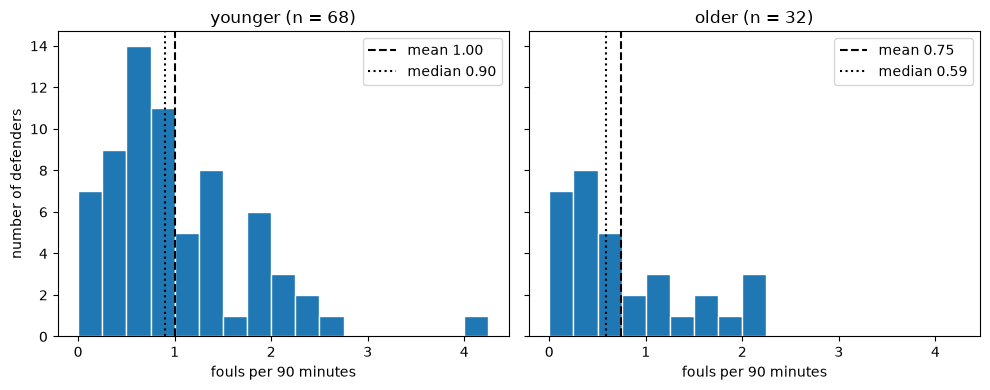

In [29]:
import matplotlib.pyplot as plt

bins = np.arange(0, 4.5, 0.25)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, group in zip(axes, ["younger", "older"]):
    values = sample.loc[sample["age_group"] == group, "fouls_per_90"]
    ax.hist(values, bins=bins, edgecolor="white")
    ax.axvline(values.mean(), color="black", linestyle="--", label=f"mean {values.mean():.2f}")
    ax.axvline(values.median(), color="black", linestyle=":", label=f"median {values.median():.2f}")
    ax.set_title(f"{group} (n = {len(values)})")
    ax.set_xlabel("fouls per 90 minutes")
    ax.legend()
axes[0].set_ylabel("number of defenders")
plt.tight_layout()
plt.show()

## Interpretation

Both groups are right-skewed.

Most defenders are below one foul per 90 with a tail to the right.

The older group is shifted to the left. Its peak is at 0.25-0.5 fouls per 90 vs 0.5-1.0 for the younger group. Its mean and median are both ~0.25-0.3 lower.

The older group's bars are roughly half the height of the younger group's because we are showing a histogram on count, and the older group has roughly half the number of players of the younger group, so the overall height of the younger group likely represents group size, not necessarily increased fouling. The older group's tail is also shorter (maximum 2.0-2.25 vs 4.0-4.25), however the 4.0-4.25 value is a single player and may be explained by a larger group having more chances to reach extreme values.

This analysis points  to older defenders committing fewer fouls per 90 minutes than younger defenders.

## Inferential Statistics: Confidence Interval

A 95% confidence interval for a population mean is

$$CI = \bar{x} \pm z^* \cdot \frac{s}{\sqrt{n}}$$

$s/\sqrt{n}$ is the standard error
$z^* = 1.960$ for a 95% confidence level

Both groups have at least 30 defenders (older 32, younger 68), so by the Week 3 rule $z^*$ is used rather than $t^*$. The population standard deviation is unknown, so the sample standard deviation $s$ is used in its place.

Referring to the practical scripts from week 3.

We then check each interval against the actual population mean for that group.

In [30]:
import math
import scipy.stats as st
import statsmodels.stats.weightstats as stm

conf_lvl = 0.95
sig_lvl = 1 - conf_lvl
z_score = st.norm.ppf(q=1 - sig_lvl / 2)
print("Confidence level: %.2f. z-statistic: %.3f" % (conf_lvl, z_score))
print()

ci = {}
for group in ["older", "younger"]:
    values = sample.loc[sample["age_group"] == group, "fouls_per_90"].to_numpy(dtype=float)

    # basic statistics of the sample group
    x_bar = st.tmean(values)
    s = st.tstd(values)
    n = len(values)

    # standard error and margin of error
    std_err = s / math.sqrt(n)
    mrg_err = z_score * std_err

    # confidence interval, step by step and via statsmodels
    ci_low = x_bar - mrg_err
    ci_upp = x_bar + mrg_err
    ci_low_stm, ci_upp_stm = stm._zconfint_generic(x_bar, std_err, alpha=sig_lvl, alternative="two-sided")
    ci[group] = (ci_low, ci_upp)

    print("%s defenders" % group)
    print("  Mean: %.3f. Standard deviation: %.3f. Size: %d." % (x_bar, s, n))
    print("  Standard error: %.3f. Margin of error: %.3f." % (std_err, mrg_err))
    print("  95%% C.I. of the mean: %.3f to %.3f (statsmodels: %.3f to %.3f)" % (ci_low, ci_upp, ci_low_stm, ci_upp_stm))
    print()

Confidence level: 0.95. z-statistic: 1.960

older defenders
  Mean: 0.747. Standard deviation: 0.675. Size: 32.
  Standard error: 0.119. Margin of error: 0.234.
  95% C.I. of the mean: 0.513 to 0.981 (statsmodels: 0.513 to 0.981)

younger defenders
  Mean: 1.000. Standard deviation: 0.743. Size: 68.
  Standard error: 0.090. Margin of error: 0.177.
  95% C.I. of the mean: 0.823 to 1.177 (statsmodels: 0.823 to 1.177)


### Checking the intervals against the population

The interval says the method is expected to capture the true population mean in 95% of samples. Because we have the full population data, we can check directly.

In [31]:
for group in ["older", "younger"]:
    mu = population.loc[population["age_group"] == group, "fouls_per_90"].mean()
    low, upp = ci[group]
    inside = low <= mu <= upp
    print("%s: population mean = %.3f, interval %.3f to %.3f is %s" % (group, mu, low, upp, "inside" if inside else "OUTSIDE"))

older: population mean = 0.873, interval 0.513 to 0.981 is inside
younger: population mean = 1.016, interval 0.823 to 1.177 is inside

### Interpretation

For the older group our estimates had the population mean fouls per 90 at 0.75, with a 95% CI of 0.51 to 0.98
For the younger defenders the estimate is 1.00, with an interval of 0.82 to 1.18.

The older group's interval is wider (0.47 against 0.35) because it has fewer players.

A 95% confidence interval means that the method captures the true population mean in 95% of samples. Because the population is available here, the check can be made directly: the true means are 0.87 (older) and 1.02 (younger), and both fall inside their intervals.

The two intervals overlap between 0.82 and 0.98. The two-sample t-test tests whether there is evidence that the population means differ.

## Inferential Statistics: Two-Sample t-Test

Following the Week 4 four-step process.

**Step 1: State.** In the population of defenders who played at least 90 minutes, do older defenders (30 and over) commit fewer fouls per 90 than younger defenders?

**Step 2: Plan.** The parameters are the population mean fouls per 90 of each group. The question has a direction, so the test is one-sided:

- $H_0: \mu_{\text{older}} = \mu_{\text{younger}}$
- $H_a: \mu_{\text{older}} < \mu_{\text{younger}}$

Two-sample t-test at significance level 0.05, using the unequal-variance form of $t^*$ from Week 4.

**Step 3: Solve.** Conditions for inference:

- *Random sampling*: the sample was drawn by simple random sampling, and each defender is in exactly one group.
- *Normality*: both groups are right-skewed (histograms above), so the p-value is approximate; both have at least 30 defenders (32, 68), which the Week 3 CLT guidance requires.
- *Variances*: similar (SD 0.68 and 0.74) but not assumed equal.

Code follows the Week 4 practical script (`exe4_2_two-sample-t-test.py`).

In [32]:
# split the sample into the two groups and take the values
sample1 = sample.loc[sample["age_group"] == "older", "fouls_per_90"].to_numpy(dtype=float)
sample2 = sample.loc[sample["age_group"] == "younger", "fouls_per_90"].to_numpy(dtype=float)

# compute basic statistics for the two samples
print("Computing basic statistics of samples ...")
x_bar1 = st.tmean(sample1)
s1 = st.tstd(sample1)
n1 = len(sample1)
print("Statistics of sample 1 (older):   %.3f (mean), %.3f (std. dev.), and %d (n)." % (x_bar1, s1, n1))

x_bar2 = st.tmean(sample2)
s2 = st.tstd(sample2)
n2 = len(sample2)
print("Statistics of sample 2 (younger): %.3f (mean), %.3f (std. dev.), and %d (n)." % (x_bar2, s2, n2))

# t-statistic by the Week 4 formula (unequal variances)
t_manual = (x_bar1 - x_bar2) / math.sqrt(s1**2 / n1 + s2**2 / n2)
df_conservative = min(n1, n2) - 1
print("Computing t* by the formula ...")
print("t-statistic (t*): %.3f, conservative degrees of freedom: %d" % (t_manual, df_conservative))
# one-sided p-value from the t-distribution with the conservative df (the t-table method)
p_conservative = st.t.cdf(t_manual, df_conservative)
print("p-value with conservative df: %.4f" % p_conservative)

# perform two-sample t-test
# null hypothesis: mean of sample 1 = mean of sample 2
# alternative hypothesis: mean of sample 1 is less than mean of sample 2 (one-sided test)
# equal_var=False: the two populations are not assumed to have equal variance
t_stats, p_val = st.ttest_ind_from_stats(x_bar1, s1, n1, x_bar2, s2, n2, equal_var=False, alternative='less')
print("Computing t* and p-value with scipy ...")
print("t-statistic (t*): %.3f" % t_stats)
print("p-value: %.4f" % p_val)

print("Conclusion:")
if p_val < 0.05:
    print("We reject the null hypothesis.")
else:
    print("We do not reject the null hypothesis.")

Computing basic statistics of samples ...
Statistics of sample 1 (older):   0.747 (mean), 0.675 (std. dev.), and 32 (n).
Statistics of sample 2 (younger): 1.000 (mean), 0.743 (std. dev.), and 68 (n).
Computing t* by the formula ...
t-statistic (t*): -1.693, conservative degrees of freedom: 31
p-value with conservative df: 0.0502
Computing t* and p-value with scipy ...
t-statistic (t*): -1.693
p-value: 0.0475
Conclusion:
We reject the null hypothesis.

**Step 4: Conclude.** $t^* = -1.69$. The p-value is 0.0475 from scipy and 0.0502 with the conservative degrees of freedom used by the t-table method. At the 0.05 level the null hypothesis is rejected by the first and not by the second. The evidence that older defenders commit fewer fouls per 90 than younger defenders is weak but present. If the null hypothesis were true, a difference this large in this direction would occur by chance about 5% of the time.

The real population means are 0.87 (older) and 1.02 (younger), so older defenders do foul less, by about 0.14 fouls per 90. The marginal p-value reflects a real but small difference measured with a sample of 100.